In [1]:
import matplotlib.pyplot as plt
import torch
from cryosim.icemaker import Icemaker
from cryosim.fft_tools import fft3
from cryosim.plotting_tools import plot3d

%load_ext autoreload
%autoreload 2

## Load Frame 100 of MD-simulation (can't upload all frames due to memory)

In [2]:
mdsim_frame100 = torch.load("../ice-data/mdsim_frame100_ice_deltas.pt")

In [3]:
mdsim_frame100.shape

torch.Size([200, 200, 200])

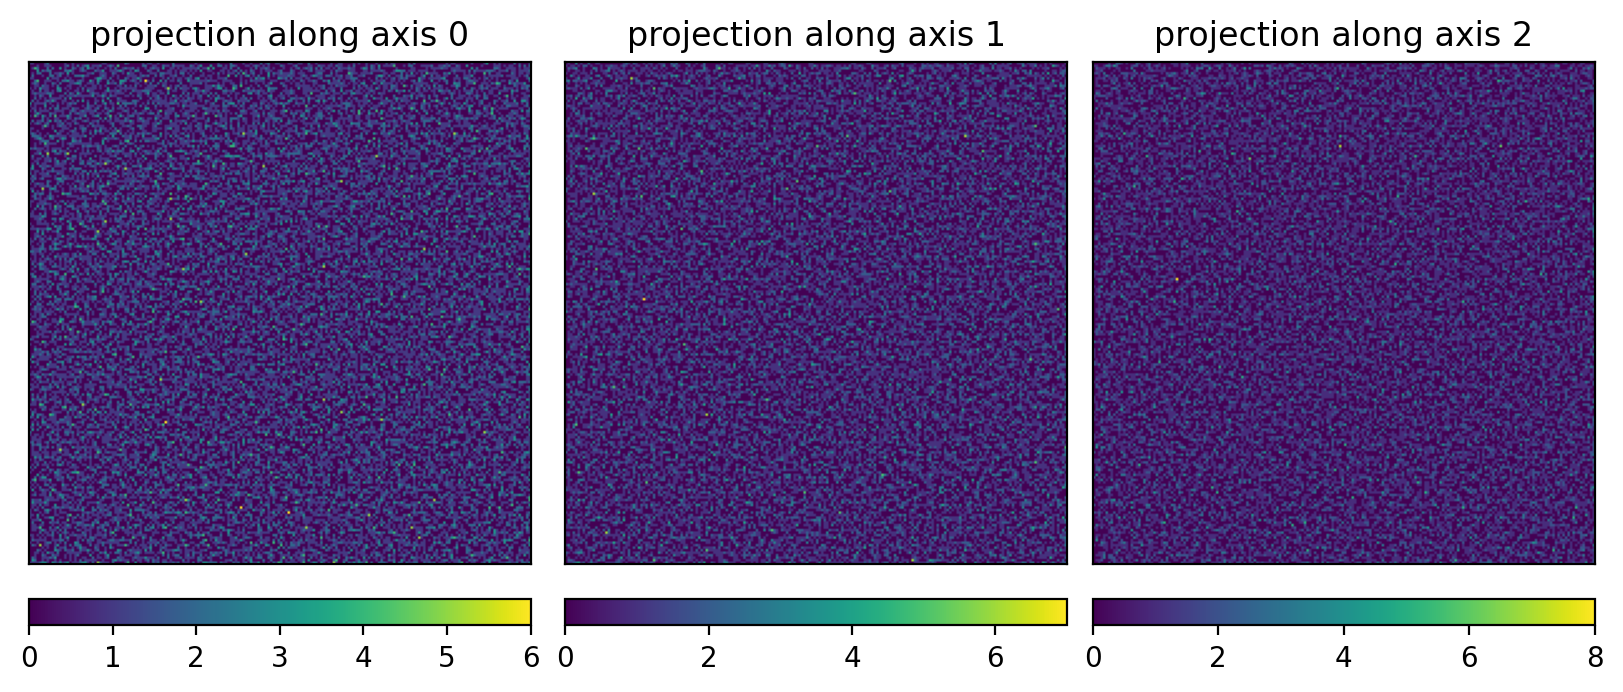

In [4]:
plot3d(mdsim_frame100)

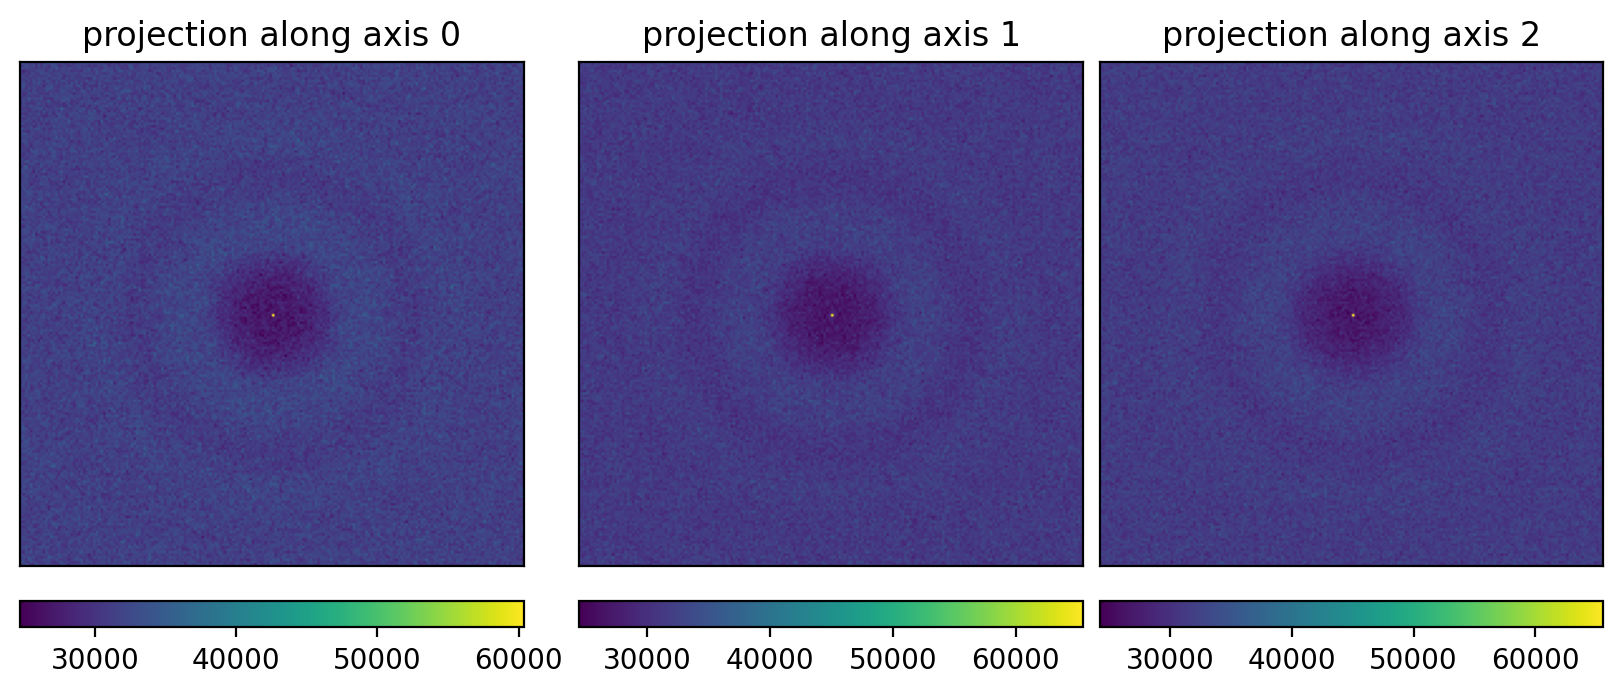

In [5]:
plot3d(torch.abs(fft3(mdsim_frame100)))

In [6]:
# Safer implementation
fft_vals = torch.fft.fftn(mdsim_frame100.float())
magnitude = torch.abs(fft_vals)

# Create random phase
phase = torch.rand_like(mdsim_frame100) * 2 * torch.pi

# Option: Ensure the DC component (0,0,0) has 0 phase
# so the sum remains a purely real positive number
phase[0, 0, 0] = 0

new_fft = magnitude * torch.exp(1j * phase)
newice = torch.fft.ifftn(new_fft).real

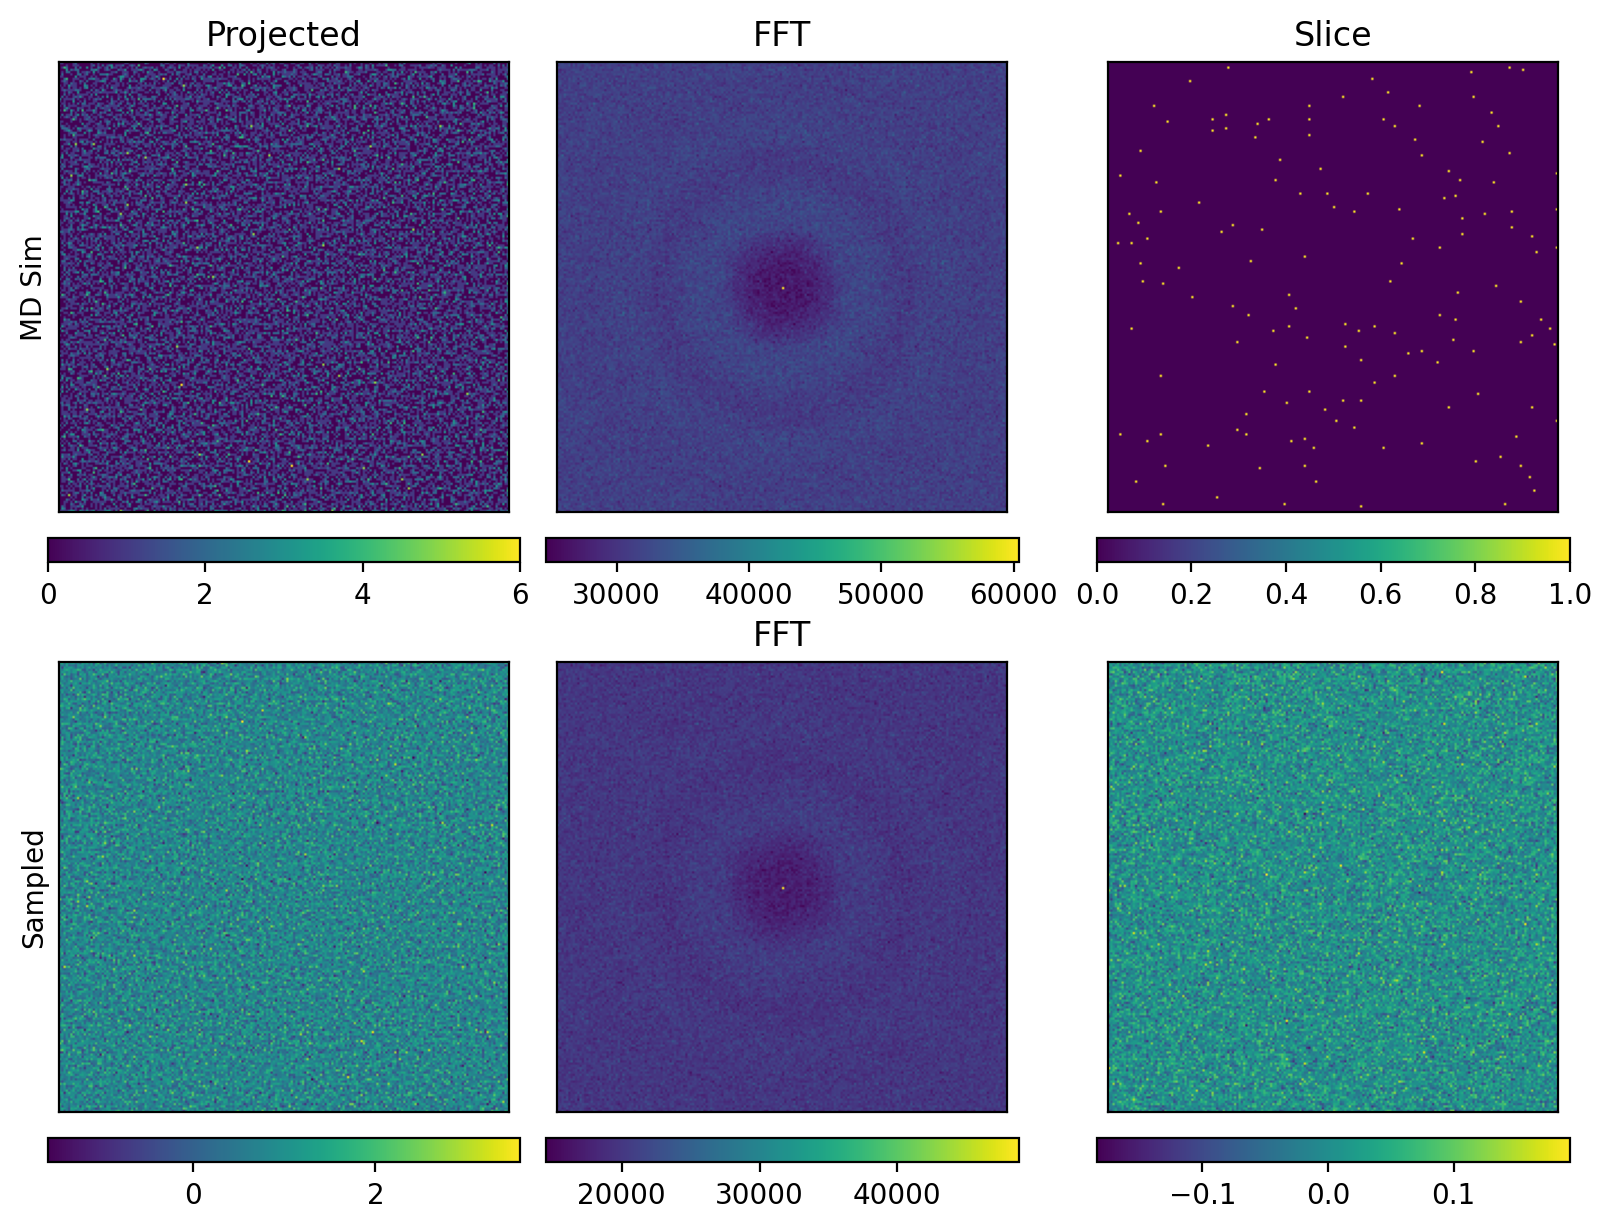

In [7]:
fig, axes = plt.subplots(2, 3, dpi=200, constrained_layout=True, figsize=(8, 6))
[ax.set(yticks=[], xticks=[]) for ax in axes.ravel()]
ax = axes[0, 0]
im = ax.imshow(mdsim_frame100.sum(0))
ax.set_title("Projected")
ax.set_ylabel("MD Sim")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[0, 1]
im = ax.imshow(torch.abs(fft3(mdsim_frame100)).sum(0))
ax.set_title("FFT")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[0, 2]
im = ax.imshow(mdsim_frame100[100])
ax.set_title("Slice")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[1, 0]
im = ax.imshow(newice.sum(0))
ax.set_ylabel("Sampled")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[1, 1]
im = ax.imshow(torch.abs(fft3(newice)).sum(0))
ax.set_title("FFT")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[1, 2]
im = ax.imshow(newice[100])
fig.colorbar(im, ax=ax, location="bottom")

plt.show()

## Big ice assembly

In [16]:
im = Icemaker(n=256, dx=1.5)

In [17]:
im.generate_ice_deltas(batchsize=8)
im.ice_vol.shape

Output()

torch.Size([8, 256, 256, 256])

In [18]:
def assemble_volume_randomized(blocks: torch.Tensor, target_shape):
    """
    Assemble a 3D volume from small blocks randomly, with random roll, flip, and rotation.

    Args:
        blocks: torch.Tensor of shape (N, 256, 256, 256)
        target_shape: tuple (A, B, C) specifying desired output shape

    Returns:
        volume: torch.Tensor of shape (A, B, C)
    """
    N, block_size, _, _ = blocks.shape
    A, B, C = target_shape

    # Compute number of blocks needed along each axis
    n_x = (A + block_size - 1) // block_size
    n_y = (B + block_size - 1) // block_size
    n_z = (C + block_size - 1) // block_size

    # Random indices for selecting blocks
    idx = torch.randint(0, N, (n_x, n_y, n_z))

    x_slices = []
    for i in range(n_x):
        y_slices = []
        for j in range(n_y):
            z_slices = []
            for k in range(n_z):
                b = blocks[idx[i, j, k]]

                # Random roll along all axes
                shift_x = torch.randint(0, block_size, (1,)).item()
                shift_y = torch.randint(0, block_size, (1,)).item()
                shift_z = torch.randint(0, block_size, (1,)).item()
                b = torch.roll(b, shifts=(shift_x, shift_y, shift_z), dims=(0, 1, 2))

                # Random flip along any axis
                if torch.rand(1) < 0.5:
                    b = torch.flip(b, dims=(0,))
                if torch.rand(1) < 0.5:
                    b = torch.flip(b, dims=(1,))
                if torch.rand(1) < 0.5:
                    b = torch.flip(b, dims=(2,))

                # Random rotation along any plane
                k_rot_xy = torch.randint(0, 4, (1,)).item()  # rotate in xy plane
                b = torch.rot90(b, k=k_rot_xy, dims=(0, 1))
                k_rot_xz = torch.randint(0, 4, (1,)).item()  # rotate in xz plane
                b = torch.rot90(b, k=k_rot_xz, dims=(0, 2))
                k_rot_yz = torch.randint(0, 4, (1,)).item()  # rotate in yz plane
                b = torch.rot90(b, k=k_rot_yz, dims=(1, 2))

                z_slices.append(b)
            # Concatenate along depth (z)
            y_slices.append(torch.cat(z_slices, dim=2))
        # Concatenate along width (y)
        x_slices.append(torch.cat(y_slices, dim=1))
    # Concatenate along height (x)
    full_volume = torch.cat(x_slices, dim=0)

    # Crop to target shape
    return full_volume[:A, :B, :C]


def assemble_volume_simple(blocks: torch.Tensor, target_shape):
    """
    Assemble a 3D volume from small blocks in a regular grid.

    Args:
        blocks: torch.Tensor of shape (N, 256, 256, 256)
        target_shape: tuple (A, B, C) specifying desired output shape

    Returns:
        volume: torch.Tensor of shape (A, B, C)
    """
    N, block_size, _, _ = blocks.shape
    A, B, C = target_shape

    # Compute number of blocks along each axis
    n_x = (A + block_size - 1) // block_size
    n_y = (B + block_size - 1) // block_size
    n_z = (C + block_size - 1) // block_size

    # Randomly choose block indices
    idx = torch.randint(0, N, (n_x, n_y, n_z))

    x_slices = []
    for i in range(n_x):
        y_slices = []
        for j in range(n_y):
            z_slices = [blocks[idx[i, j, k]] for k in range(n_z)]
            y_slices.append(torch.cat(z_slices, dim=2))  # depth
        x_slices.append(torch.cat(y_slices, dim=1))  # width
    full_volume = torch.cat(x_slices, dim=0)  # height

    # Crop to target shape
    return full_volume[:A, :B, :C]

In [19]:
def replace_outer_faces_batch(tensors):
    """
    Replace the 6 outer faces of a batch of 3D tensors with random inner slices.

    Args:
        tensors: torch.Tensor of shape (N, D, H, W)

    Returns:
        tensors: modified in-place
    """
    N, D, H, W = tensors.shape

    if D <= 2 or H <= 2 or W <= 2:
        raise ValueError("Tensor too small to have inner slices")

    for n in range(N):
        # Select random inner indices for each axis
        z_idx = torch.randint(1, D - 1, (1,)).item()
        y_idx = torch.randint(1, H - 1, (1,)).item()
        x_idx = torch.randint(1, W - 1, (1,)).item()

        # Front/back faces (along depth)
        tensors[n, 0, :, :] = tensors[n, z_idx, :, :]
        tensors[n, -1, :, :] = tensors[n, z_idx, :, :]

        # Top/bottom faces (along height)
        tensors[n, :, 0, :] = tensors[n, :, y_idx, :]
        tensors[n, :, -1, :] = tensors[n, :, y_idx, :]

        # Left/right faces (along width)
        tensors[n, :, :, 0] = tensors[n, :, :, x_idx]
        tensors[n, :, :, -1] = tensors[n, :, :, x_idx]

    return tensors

In [20]:
nices = replace_outer_faces_batch(im.ice_vol.detach().cpu().clone())

In [21]:
final = assemble_volume_randomized(nices, (1024, 1024, 1024))

In [25]:
final_bad = assemble_volume_simple(
    im.ice_vol.detach().cpu().clone(), (1024, 1024, 1024)
)

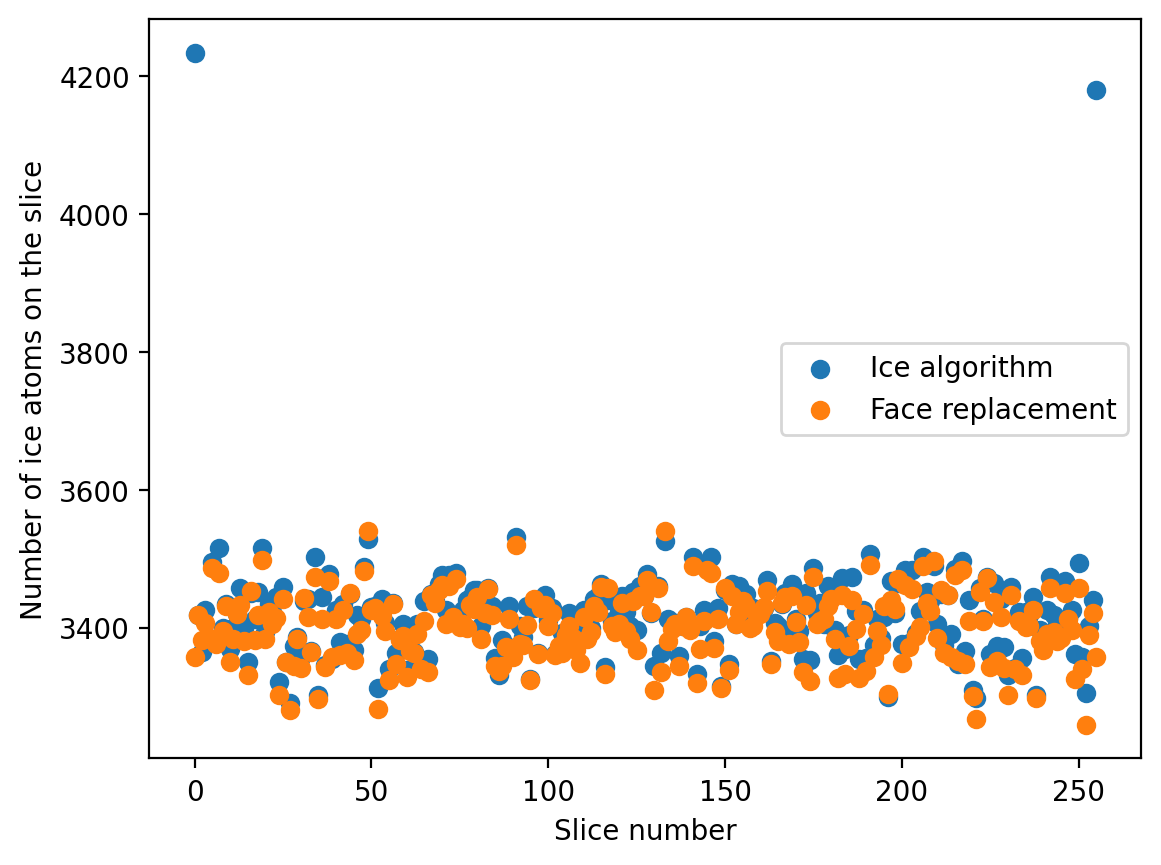

In [30]:
idx = 0
plt.figure(dpi=200)
plt.scatter(
    range(256),
    torch.sum(im.ice_vol.detach().cpu()[idx], dim=(1, 2)),
    label="Ice algorithm",
)
plt.scatter(range(256), torch.sum(nices[idx], dim=(1, 2)), label="Face replacement")
plt.xlabel("Slice number")
plt.ylabel("Number of ice atoms on the slice")
plt.legend()
plt.show()

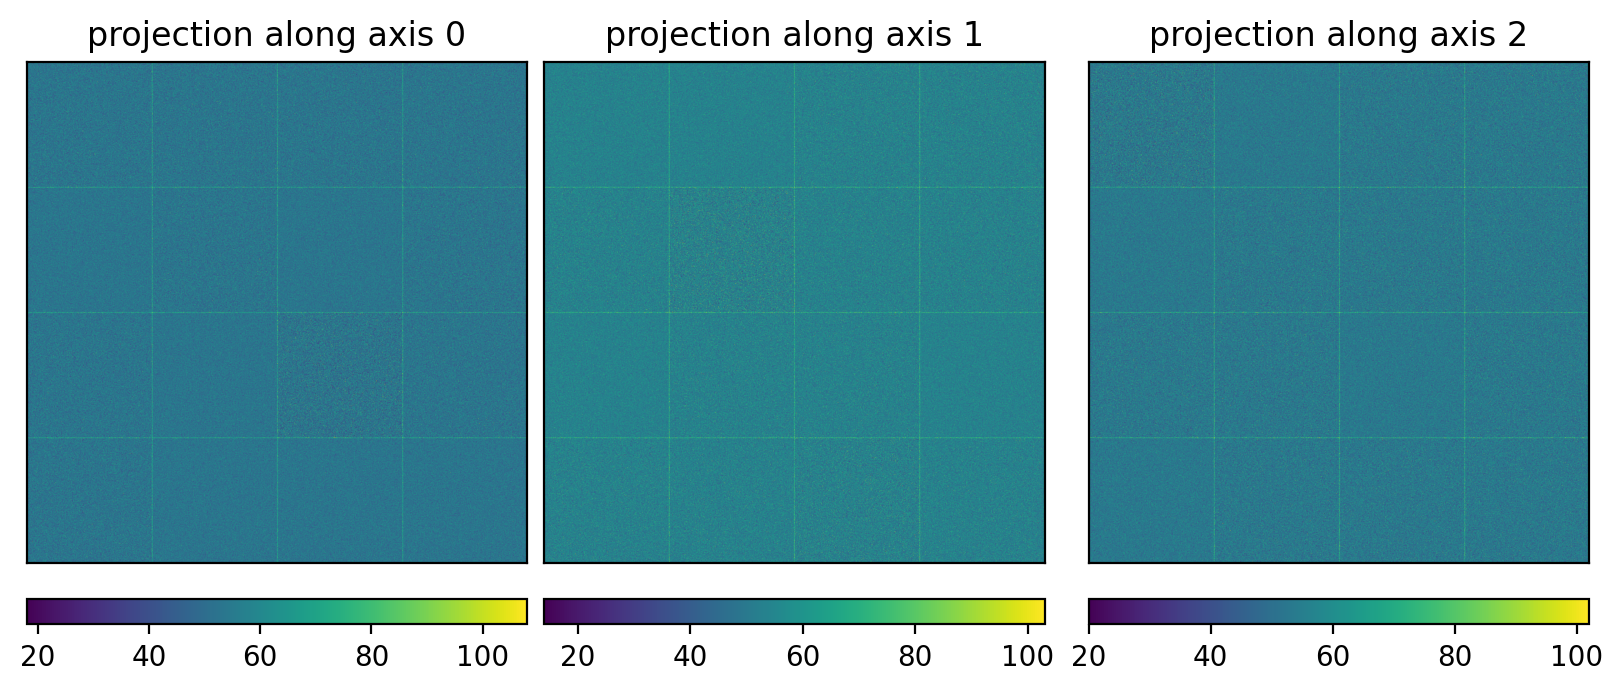

In [26]:
plot3d(final_bad)

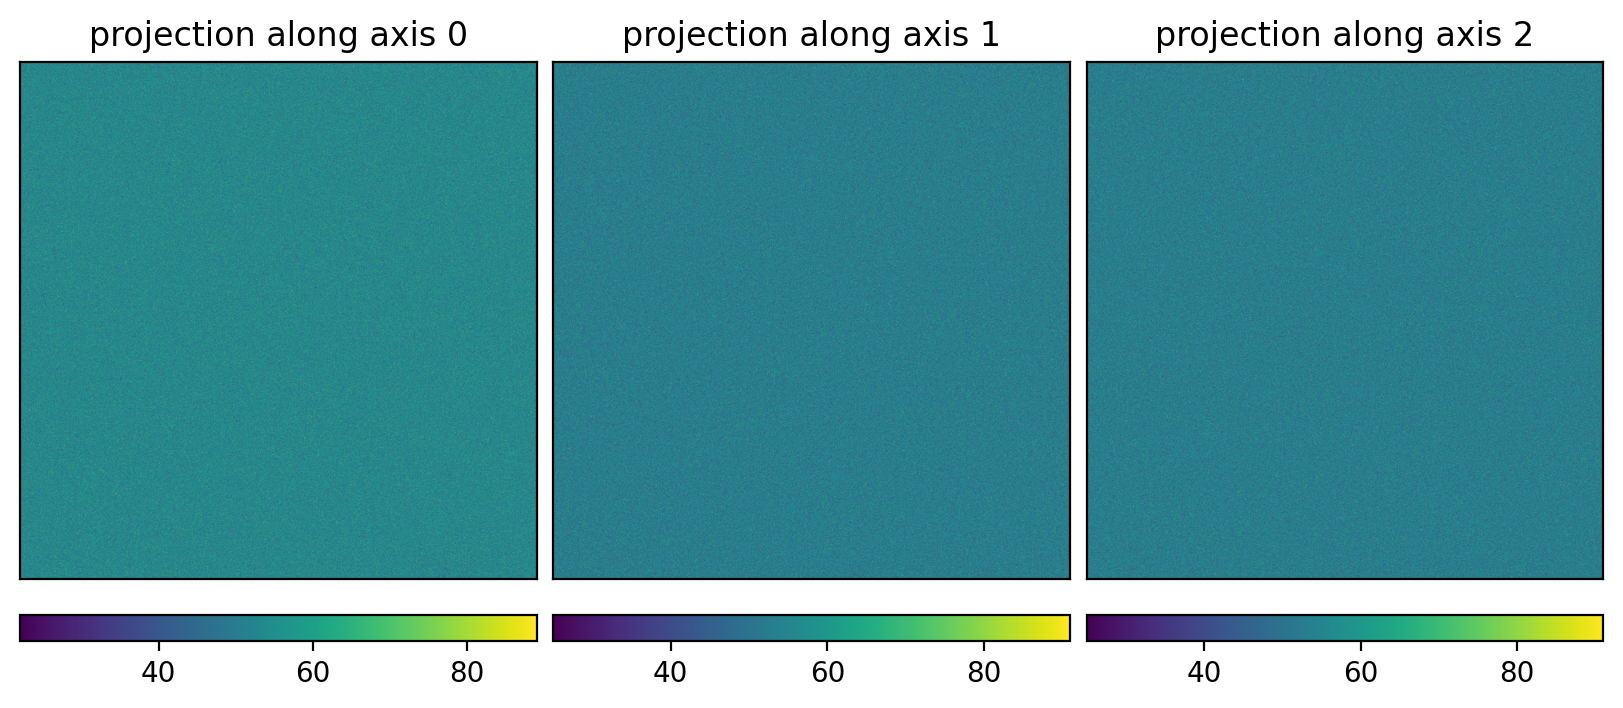

In [24]:
plot3d(final)

In [ ]:
plot3d(torch.abs(torch.log(fft3(final))))